In [2]:
using Pkg
Pkg.activate(@__DIR__)

using Revise

includet("Anderson.jl")
using .Anderson

Pkg.add("Plots")
using Plots

Pkg.add("MatrixDepot")
using MatrixDepot

  Activating project at `~/stuff/MIM/research-project`
     Project No packages added to or removed from `~/stuff/MIM/research-project/Project.toml`
    Manifest No packages added to or removed from `~/stuff/MIM/research-project/Manifest.toml`
     Project No packages added to or removed from `~/stuff/MIM/research-project/Project.toml`
    Manifest No packages added to or removed from `~/stuff/MIM/research-project/Manifest.toml`
┌ Info: verify download of index files...
└ @ MatrixDepot /home/jlakomy/.julia/packages/MatrixDepot/q3dd8/src/MatrixDepot.jl:117
┌ Info: reading database
└ @ MatrixDepot /home/jlakomy/.julia/packages/MatrixDepot/q3dd8/src/download.jl:26
┌ Info: adding metadata...
└ @ MatrixDepot /home/jlakomy/.julia/packages/MatrixDepot/q3dd8/src/download.jl:72
┌ Info: adding svd data...
└ @ MatrixDepot /home/jlakomy/.julia/packages/MatrixDepot/q3dd8/src/download.jl:74
┌ Info: writing database
└ @ MatrixDepot /home/jlakomy/.julia/packages/MatrixDepot/q3dd8/src/download.jl:79
┌ 

In [3]:
function plot_residuals(title::String, names::AbstractArray{String}, residuals::AbstractArray) 
    p = plot(title=title, yscale=:log10, titlefontsize=8)
    for (name, res) in zip(names, residuals)
        plot!(p, res, label = name)
    end
    display(p)
end

plot_residuals (generic function with 1 method)

## Porównanie z metodą newtona - liniowa zbieżność

In [4]:
function anderson_vs_newton(x0::AbstractFloat, g, g_str::AbstractString, dg, m=10::Integer, β = 1.0::AbstractFloat, tol=1e-6::AbstractFloat, max_iter=100::Integer)
    x, stats = scalar_newton(x0, g, dg)
    x_anderson, stats_anderson = anderson([x0], x -> [g(x[1])], 10) 
    anderson_ys = stats_anderson.residual_history

    newton_ys = stats.residual_history

    plot_residuals(
        "Porównanie zbieżności metod Andersona i Newtona dla funkcji g(x) = $g_str",
        ["metoda Andersona", "Metoda Newtona"],
        [anderson_ys, newton_ys]
    )

end

anderson_vs_newton (generic function with 5 methods)

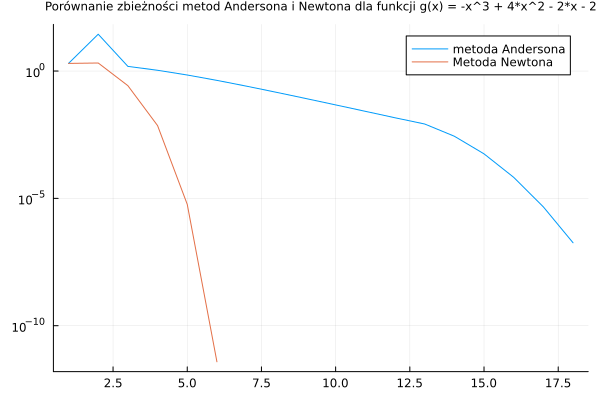

In [5]:
f = x -> x^3 - 4*x^2 + 3*x + 2
    g = x -> x - f(x)
    dg = x -> 1 - 3*x^2 + 8*x - 3

    x0 = 0.0


anderson_vs_newton(x0, g, "-x^3 + 4*x^2 - 2*x - 2", dg)

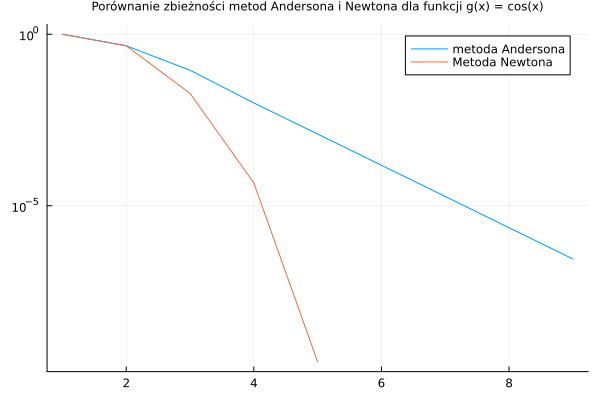

In [6]:
g = x -> cos(x)
dg = x -> -sin(x)
x0 = 0.0

anderson_vs_newton(x0, g, "cos(x)", dg)

## Przypadek liniowy - równoważność z GMRES i porównanie z Conjugate Gradient

In [7]:
Pkg.add("Krylov")
using Krylov

     Project No packages added to or removed from `~/stuff/MIM/research-project/Project.toml`
    Manifest No packages added to or removed from `~/stuff/MIM/research-project/Manifest.toml`


(stats_cg.niter, stats_cg.residuals[end]) = (400, 1.5022127334067061e-12)
(stats_gmres.niter, stats_gmres.residuals[end]) = (400, 6.4196666088893764e-15)
(stats_a.iterations, stats_a.residual) = (400, 2.8967419235595705e-10)


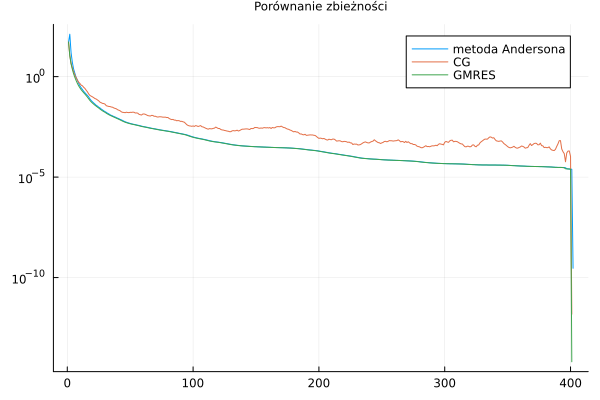

In [28]:
using LinearAlgebra

n = 400
A = matrixdepot("tridiag", n)
solution = randn(n)
b = A * solution

x0 = zeros(n)
g = x -> x - (A * x - b)


x_cg, stats_cg = cg(A, b, x0, atol=1e-6,history=true, itmax = 500)

@show stats_cg.niter, stats_cg.residuals[end]

x_gmres, stats_gmres = gmres(A, b, x0, atol=1e-6,history=true, itmax = 500)

@show stats_gmres.niter, stats_gmres.residuals[end]

x_a, stats_a  = anderson(x0, g, typemax(Int),tol=1e-6, max_iter = 500)

@show stats_a.iterations, stats_a.residual

plot_residuals("Porównanie zbieżności", ["metoda Andersona", "CG", "GMRES"], [stats_a.residual_history, stats_cg.residuals, stats_gmres.residuals])

## Problem Bratu - wpływ parametrów na zbieżność

In [32]:
function bratu(x; λ = 0.5, μ = 0.1)
    m = isqrt(length(x))
    h = 1 / (m + 1)
    U = reshape(x, m, m)
    F = reshape(similar(x), m, m)
    for j in 1:m, i in 1:m
        center  = U[i, j]
        up = i == 1 ? 0.0 : U[i-1, j]
        down = i == m ? 0.0 : U[i+1, j]
        left = j == 1 ? 0.0 : U[i, j-1]
        right = j == m ? 0.0 : U[i, j+1]
        F[i,j] = (up + down + left + right - 4center) + h^2 * λ * exp(center)
    end
    return x - μ * vec(F)
end

n= 20^2
g = x -> bratu(x)
x0 = zeros(n);


(β, stats.iterations, stats.residual) = (0.1, 63, 8.645074823104548e-7)
(β, stats.iterations, stats.residual) = (0.5, 38, 9.619189228705905e-7)
(β, stats.iterations, stats.residual) = (1.0, 36, 7.784303215911479e-7)
(β, stats.iterations, stats.residual) = (1.5, 36, 7.634669013167038e-7)
(β, stats.iterations, stats.residual) = (2.0, 36, 9.062924237283858e-7)
(β, stats.iterations, stats.residual) = (10.0, 35, 7.983317203601916e-7)


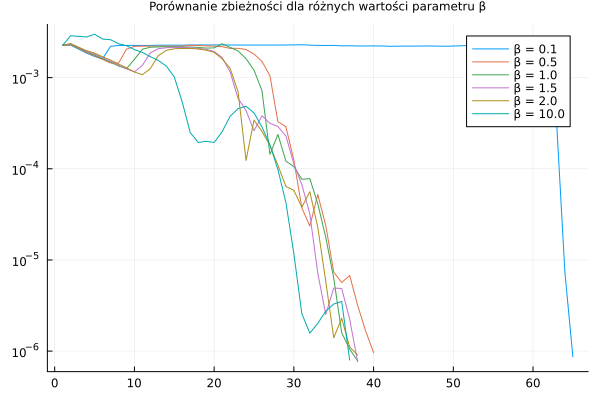

In [33]:
residuals = []
βs = [0.1, 0.5, 1.0, 1.5,2.0, 10.0]

for β in βs
    x , stats = anderson(x0, g, 60, β=β, max_iter=500)
    @show β, stats.iterations, stats.residual
    push!(residuals, stats.residual_history)
end


plot_residuals("Porównanie zbieżności dla różnych wartości parametru β", (β -> "β = $β").(βs), residuals)

(m, stats.iterations, stats.residual) = (10, 98, 9.269604915915694e-7)
(m, stats.iterations, stats.residual) = (20, 44, 6.715536428825194e-7)
(m, stats.iterations, stats.residual) = (30, 35, 1.724708064408226e-8)
(m, stats.iterations, stats.residual) = (40, 36, 7.784303215911479e-7)
(m, stats.iterations, stats.residual) = (50, 36, 7.784303215911479e-7)
(m, stats.iterations, stats.residual) = (9223372036854775807, 36, 7.784303215911479e-7)


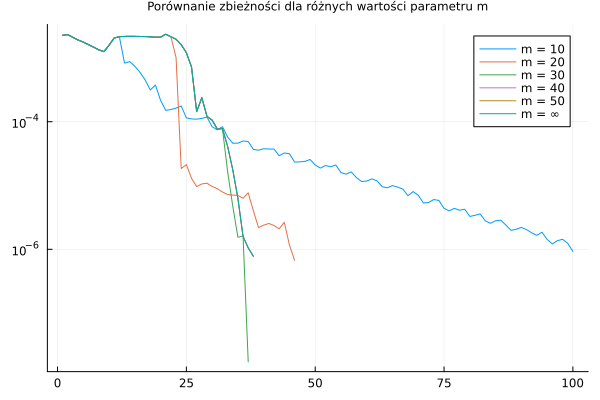

In [35]:
residuals = []
ms = [10,20,30,40, 50,typemax(Int)]
for m in ms
    x , stats = anderson(x0, g, m, max_iter=500)
    @show m, stats.iterations, stats.residual
    push!(residuals, stats.residual_history)
end


plot_residuals("Porównanie zbieżności dla różnych wartości parametru m", (m -> m != typemax(Int) ? "m = $m" : "m = ∞").(ms), residuals)